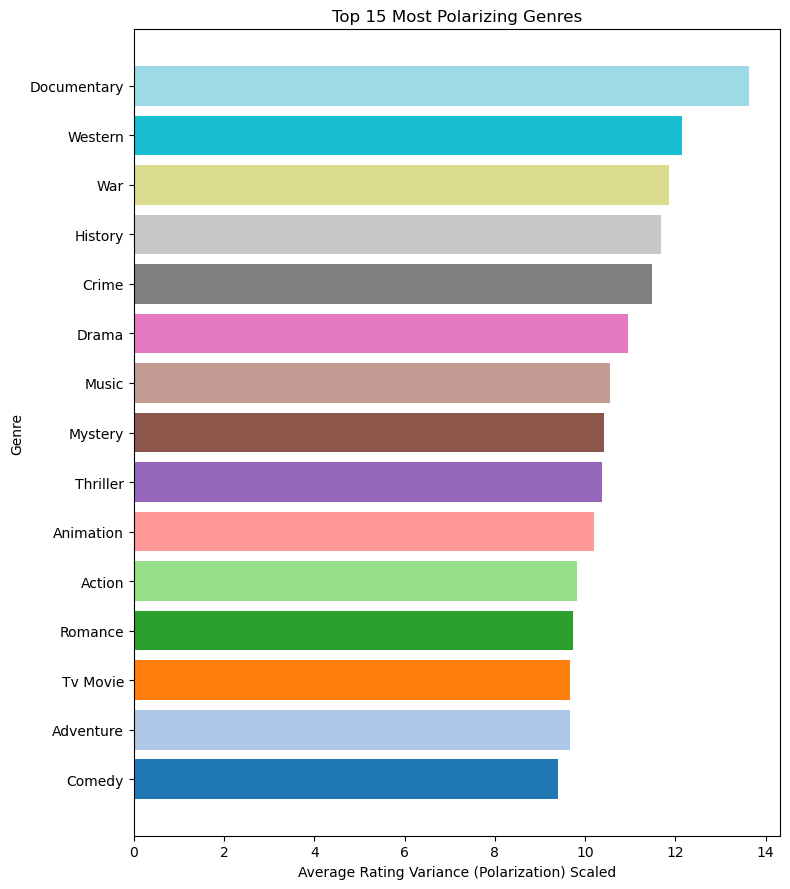

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import ast
import pandas as pd

# Read data into notebook
df = pd.read_csv("Movie_Data_File.csv")

star_cols = [
    "½",
    "★",
    "★½",
    "★★",
    "★★½",
    "★★★",
    "★★★½",
    "★★★★",
    "★★★★½",
    "★★★★★"
]

# Remove rows without genre
df = df.dropna(subset=["Genres"])

# Genres are comma-separated so split and explode
df["Genres"] = df["Genres"].apply(ast.literal_eval)
df = df.explode("Genres")
# Need to clean genres formatting
df["Genres"] = (
    df["Genres"]
    .str.strip() # Remove leading/trailing spaces
    .str.title() # Standardize capitalization
)

# Calculate total ratings per film
df["Total_Ratings_Calc"] = df[star_cols].sum(axis=1)

# Convert star counts into proportions
for col in star_cols:
    df[col + "_prop"] = df[col] / df["Total_Ratings_Calc"]

prop_cols = [col + "_prop" for col in star_cols]

# Compute variance across rating proportions (polarization metric)
df["rating_variance"] = df[prop_cols].var(axis=1)

# Average polarization per genre
genre_polarization = (
    df.groupby("Genres")["rating_variance"]
    .mean()
    .sort_values(ascending=False)
)

# Show only top 15 most polarized genres for readability
top_n = 15
top_genres = genre_polarization.head(top_n)
top_genres_scaled = top_genres * 1000
sorted_genres = top_genres_scaled.sort_values()
colors = plt.cm.tab20(np.linspace(0, 1, len(sorted_genres)))

plt.figure(figsize=(8, 9))
plt.barh(
    sorted_genres.index,
    sorted_genres.values,
    color=colors
)
plt.xlabel("Average Rating Variance (Polarization) Scaled")
plt.ylabel("Genre")
plt.title("Top 15 Most Polarizing Genres")
plt.tight_layout()
plt.show()

In [2]:
# Assistant
def assign_quadrant(row):
    if row["Average_Rating"] >= rating_median and row["Reviews_Millions"] >= review_median:
        return "Acclaimed blockbusters"
    elif row["Average_Rating"] < rating_median and row["Reviews_Millions"] >= review_median:
        return "Commercial triumphs"
    elif row["Average_Rating"] >= rating_median and row["Reviews_Millions"] < review_median:
        return "Cult classics"
    else:
        return "Underperformers"

top_movies["Quadrant"] = top_movies.apply(assign_quadrant, axis=1)

# color map for quadrants
colors = {
    "Acclaimed blockbusters": "green",
    "Commercial triumphs": "orange",
    "Cult classics": "blue",
    "Underperformers": "gray"
}

plt.figure(figsize=(11, 9))

# plot points
for quad in colors:
    subset = top_movies[top_movies["Quadrant"] == quad]
    plt.scatter(
        subset["Average_Rating"],
        subset["Reviews_Millions"],
        label=quad,
        color=colors[quad],
        alpha=0.7
    )

# add quadrant lines
plt.axvline(rating_median, linestyle="--", color="black")
plt.axhline(review_median, linestyle="--", color="black")

# label top 10 most reviewed films in each quadrant
for quad in top_movies["Quadrant"].unique():
    
    quad_subset = top_movies[top_movies["Quadrant"] == quad]
    

# compute distance from quadrant center
top_movies["distance"] = np.sqrt(
    (top_movies["Average_Rating"] - rating_median) ** 2 +
    (top_movies["Reviews_Millions"] - review_median) ** 2
)

# label 5 most extreme films in each quadrant
for quad in top_movies["Quadrant"].unique():
    
    quad_subset = top_movies[top_movies["Quadrant"] == quad]
    
    # pick 5 farthest from the median intersection
    extreme_movies = quad_subset.sort_values(
        "distance",
        ascending=False
    ).head(5)
    
    for _, row in extreme_movies.iterrows():
        plt.annotate(
            row["Film_title"],
            (row["Average_Rating"], row["Reviews_Millions"]),
            fontsize=7
        )

plt.xlabel("Average Rating")
plt.ylabel("Reviews (Millions)")
plt.title("Popularity vs Rating: Quadrant Analysis of Top 150 Films")
plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'top_movies' is not defined

In [4]:
# Average Rating vs Watches by top 20 Languages (Side-by-Side)

import altair as alt

lang_df = pd.read_csv("Movie_Data_File.csv").copy()
lang_df = lang_df.dropna(subset=["Original_language", "Watches", "Average_rating"])
lang_df = lang_df[lang_df["Original_language"] != "No spoken language"]
lang_df = lang_df[lang_df["Watches"] > 0]

# Aggregate per language
lang_agg = lang_df.groupby("Original_language").agg(
    total_watches=("Watches", "sum"),
    avg_rating=("Average_rating", "mean"),
    film_count=("Watches", "count")
).reset_index()

# Top 20 languages by film count
lang_agg = lang_agg.nlargest(20, "film_count").reset_index(drop=True)

# Convert to millions
lang_agg["watches_millions"] = (lang_agg["total_watches"] / 1_000_000).round(2)

# 20 visually distinct colors
legend_color = [
    "#e6194b", "#3cb44b", "#ffe119", "#4363d8", "#f58231",
    "#911eb4", "#42d4f4", "#f032e6", "#bfef45", "#fabed4",
    "#469990", "#dcbeff", "#9a6324", "#c45c00", "#800000",
    "#aaffc3", "#808000", "#c47a00", "#000075", "#a9a9a9"
]

# Split into two dataframes
all_langs   = lang_agg.copy()
non_english = lang_agg[lang_agg["Original_language"] != "English"].copy()

selection = alt.selection_point()

def make_chart(data, title):
    return alt.Chart(data).mark_point(filled=True, size=120).encode(
        x=alt.X("avg_rating:Q", title="Average Rating",
                scale=alt.Scale(domain=[3, 4])),
        y=alt.Y("watches_millions:Q", title="Total Watches (Millions)"),
        color=alt.condition(
            selection,
            alt.Color("Original_language:N",
                      scale=alt.Scale(domain=lang_agg["Original_language"].tolist(),
                                      range=legend_color),
                      legend=alt.Legend(title="Language")),
            alt.value("lightgrey")
        ),
        tooltip=[
            alt.Tooltip("Original_language:N", title="Language"),
            alt.Tooltip("avg_rating:Q", title="Avg Rating", format=".2f"),
            alt.Tooltip("watches_millions:Q", title="Watches (M)", format=".1f"),
            alt.Tooltip("film_count:Q", title="Number of Films")
        ]
    ).add_params(
        selection
    ).properties(
        title=title,
        width=380,
        height=400
    )

chart_all    = make_chart(all_langs,   "Top 20 Languages: Including English)")
chart_no_eng = make_chart(non_english, "Top 20 Non-English Languages")

(chart_all | chart_no_eng)

alt.HConcatChart(...)

In [5]:
# Top 10 Films by Language

import altair as alt
import ast

# Load data & remove misssing key fields
films_df = pd.read_csv("Movie_Data_File.csv").copy()
films_df = films_df.dropna(subset=["Original_language", "Average_rating", "Film_title", "Genres"])
films_df = films_df[films_df["Original_language"] != "No spoken language"]

# Explode genres so each film / genre pair is within its own row 
films_df["Genres"] = films_df["Genres"].apply(ast.literal_eval)
films_df = films_df.explode("Genres")
films_df["Genres"] = films_df["Genres"].str.strip().str.title()

# Get sorted unique languages and genres used for dropdowns 
languages = sorted(films_df["Original_language"].unique().tolist())
genres    = ["All"] + sorted(films_df["Genres"].unique().tolist())

# Identify top 10 films and genres for dropdowns 
rows = []
for lang in languages:
    lang_films = films_df[films_df["Original_language"] == lang]

    # Across all genres (if user doesn't input the specific genre)
    top10_all = (
        lang_films.groupby("Film_title").agg(
            Average_rating=("Average_rating", "mean")
        ).reset_index()
        .sort_values("Average_rating", ascending=False)
        .head(10).reset_index(drop=True)
    )
    for i, r in top10_all.iterrows():
        rows.append({
            "Film_title":        r["Film_title"],
            "Original_language": lang,
            "Genre":             "All",
            "Average_rating":    round(r["Average_rating"], 2),
            "rank":              i + 1
        })
    # Across both genre AND language selection
    for genre in lang_films["Genres"].unique():
        top10_genre = (
            lang_films[lang_films["Genres"] == genre]
            .groupby("Film_title").agg(
                Average_rating=("Average_rating", "mean")
            ).reset_index()
            .sort_values("Average_rating", ascending=False)
            .head(10).reset_index(drop=True)
        )
        for i, r in top10_genre.iterrows():
            rows.append({
                "Film_title":        r["Film_title"],
                "Original_language": lang,
                "Genre":             genre,
                "Average_rating":    round(r["Average_rating"], 2),
                "rank":              i + 1
            })

prebuilt = pd.DataFrame(rows)

# Dropdowns
language_param = alt.param(
    name="language_val",
    bind=alt.binding_select(options=languages, name="Language: "),
    value=languages[0]
)
genre_param = alt.param(
    name="genre_val",
    bind=alt.binding_select(options=genres, name="Genre: "),
    value="All"
)

# Base chart filtered by dropdown selections 
base = alt.Chart(prebuilt).transform_filter(
    "datum.Original_language === language_val"
).transform_filter(
    "datum.Genre === genre_val"
)

# Horizontal bars colored by rating 
bars = base.mark_bar().encode(
    x=alt.X("Average_rating:Q", title="Average Rating",
            scale=alt.Scale(domain=[0, 5])),
    y=alt.Y("rank:O", title=None, axis=None,
            scale=alt.Scale(paddingOuter=0.2, paddingInner=0.3)),
    color=alt.Color("Average_rating:Q",
                    scale=alt.Scale(scheme="blues"),
                    legend=None),
    tooltip=[
        alt.Tooltip("Film_title:N",     title="Film"),
        alt.Tooltip("Genre:N",          title="Genre"),
        alt.Tooltip("Average_rating:Q", title="Rating", format=".2f"),
    ]
)

# Film title printed inside each bar 
film_labels = base.mark_text(
    align="left", dx=6, fontSize=12, color="white", fontWeight="bold"
).encode(
    x=alt.value(0),
    y=alt.Y("rank:O", axis=None,
            scale=alt.Scale(paddingOuter=0.2, paddingInner=0.3)),
    text=alt.Text("Film_title:N")
)

# Rating number printed at the end of each bar 
rating_labels = base.mark_text(
    align="left", dx=6, fontSize=12, color="#333"
).encode(
    x=alt.X("Average_rating:Q"),
    y=alt.Y("rank:O", axis=None,
            scale=alt.Scale(paddingOuter=0.2, paddingInner=0.3)),
    text=alt.Text("Average_rating:Q", format=".2f")
)

# layer bars and labels, attach dropdowns 
chart = (bars + film_labels + rating_labels).add_params(
    language_param,
    genre_param
).properties(
    title="Top 10 Rated Films by Language and Genre",
    width=500,
    height=450
)

chart

alt.LayerChart(...)